In [1]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import torch
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.two_tower_training import (  # noqa: E402
    TrainConfig,
    TwoTowerMLP,
    chronological_split,
    load_processed_two_tower_data,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PREFIX = "vehicle_sensor_subset_200ms_expanded_features"
BEST_DIR = PROJECT_ROOT / "experiments" / "static_action_two_tower" / "bestmodel_v2"
REPORT_DIR = PROJECT_ROOT / "reports" / "bestmodel_v2"
FIG_DIR = PROJECT_ROOT / "reports" / "figures" / "bestmodel_v2"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables" / "bestmodel_v2"
for path in (REPORT_DIR, FIG_DIR, TABLE_DIR):
    path.mkdir(parents=True, exist_ok=True)

checkpoint_path = BEST_DIR / "bestmodel_v2_complete_checkpoint.pt"
embedding_path = BEST_DIR / "static_action_embeddings.npz"
info_path = BEST_DIR / "bestmodel_v2_info.json"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DEVICE:", DEVICE)
print("checkpoint:", checkpoint_path)

try:
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
except TypeError:
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
with open(info_path, "r", encoding="utf-8") as f:
    best_info = json.load(f)

config = TrainConfig(**checkpoint["config"])
model = TwoTowerMLP(
    context_dim=int(checkpoint["context_dim"]),
    action_dim=int(checkpoint["action_dim"]),
    hidden=config.hidden,
    emb_dim=config.emb_dim,
    depth=config.depth,
    dropout=config.dropout,
    combine_mode=config.combine_mode,
).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

data = load_processed_two_tower_data(PROCESSED_DIR, prefix=PREFIX, utility_name="saved")
meta = data["meta"]
examples_index = data["examples_index"].reset_index(drop=True).copy()
action_names = list(meta["action_feature_names"])
static_action_names = list(checkpoint["static_action_feature_names"])
subset_key = "subset_str" if "subset_str" in examples_index.columns else "subset"

def parse_subset_nodes(label: str) -> list[int]:
    cleaned = str(label).replace("(", "").replace(")", "").replace(",", "-").replace(" ", "")
    return [int(part) for part in cleaned.split("-") if part]

def build_static_action_matrix(data: dict, static_action_names: list[str]) -> np.ndarray:
    meta = data["meta"]
    action_names = list(meta["action_feature_names"])
    examples_index = data["examples_index"].reset_index(drop=True)
    subset_labels = examples_index[subset_key].astype(str).to_numpy()
    context_names = list(meta["context_feature_names"])
    sensor_xy = {}
    for node in meta["ordered_nodes"]:
        node = int(node)
        sensor_xy[node] = (
            float(data["C_by_time"][0, context_names.index(f"n{node}_sensor_x_norm")]),
            float(data["C_by_time"][0, context_names.index(f"n{node}_sensor_y_norm")]),
        )
    slot_lookup = {}
    for label in pd.Series(subset_labels).drop_duplicates().astype(str):
        nodes = parse_subset_nodes(label)
        vals = []
        for slot_idx in range(3):
            if slot_idx < len(nodes):
                vals.extend(sensor_xy[nodes[slot_idx]])
            else:
                vals.extend([0.0, 0.0])
        slot_lookup[label] = vals
    canonical_slot_matrix = np.asarray([slot_lookup[label] for label in subset_labels], dtype=np.float32)

    parts = []
    for name in static_action_names:
        if name.startswith("slot") and name.endswith(("sensor_x_norm", "sensor_y_norm")):
            slot_number = int(name[4])
            xy_offset = 0 if name.endswith("sensor_x_norm") else 1
            parts.append(canonical_slot_matrix[:, 2 * (slot_number - 1) + xy_offset])
        else:
            parts.append(data["A_examples"][:, action_names.index(name)].astype(np.float32))
    return np.column_stack(parts).astype(np.float32)

A_static = build_static_action_matrix(data, static_action_names)
static_df = pd.DataFrame(A_static, columns=static_action_names)
static_df["subset_key"] = examples_index[subset_key].astype(str).to_numpy()
max_static_drift = float(
    (static_df.groupby("subset_key")[static_action_names].max() - static_df.groupby("subset_key")[static_action_names].min())
    .to_numpy()
    .max()
)
assert max_static_drift <= 1e-6, f"Static action drift detected: {max_static_drift}"

standardizers = checkpoint["standardizers"]
C_std = ((data["C_by_time"] - standardizers["C_mu"]) / standardizers["C_sigma"]).astype(np.float32)
A_std = ((A_static - standardizers["A_mu"]) / standardizers["A_sigma"]).astype(np.float32)
time_id_all = data["example_time_id"].astype(np.int64)

emb_npz = np.load(embedding_path, allow_pickle=True)
action_embedding_keys = [str(x) for x in emb_npz["subset_key"]]
action_embeddings_np = emb_npz["action_embeddings"].astype(np.float32)
subset_to_action_id = {key: i for i, key in enumerate(action_embedding_keys)}
action_id_all = examples_index[subset_key].astype(str).map(subset_to_action_id).to_numpy()
if pd.isna(action_id_all).any():
    missing = examples_index.loc[pd.isna(action_id_all), subset_key].astype(str).unique().tolist()
    raise ValueError(f"Subsets missing from static action embedding cache: {missing}")
action_id_all = action_id_all.astype(np.int64)

with torch.no_grad():
    C_tensor = torch.from_numpy(C_std).to(DEVICE)
    context_embeddings = model.embed_context(C_tensor).detach().cpu().numpy().astype(np.float32)

scores = np.empty(len(examples_index), dtype=np.float32)
batch_size = max(32768, config.batch_size * 4)
C_emb_tensor = torch.from_numpy(context_embeddings).to(DEVICE)
A_emb_tensor = torch.from_numpy(action_embeddings_np).to(DEVICE)
with torch.no_grad():
    for start in range(0, len(scores), batch_size):
        end = min(start + batch_size, len(scores))
        c_batch = C_emb_tensor[torch.from_numpy(time_id_all[start:end]).to(DEVICE)]
        a_batch = A_emb_tensor[torch.from_numpy(action_id_all[start:end]).to(DEVICE)]
        scores[start:end] = model.score_embeddings(c_batch, a_batch).detach().cpu().numpy().astype(np.float32)

split = chronological_split(time_id_all, n_times=len(data["C_by_time"]), train_frac=config.train_frac, val_frac=config.val_frac)
split_by_time = {}
for split_name in ("train", "val", "test"):
    for tid in split[f"{split_name}_time_ids"]:
        split_by_time[int(tid)] = split_name

score_df = examples_index.copy()
score_df["datetime"] = pd.to_datetime(score_df["datetime"])
score_df["score"] = scores
score_df["saved_utility"] = data["saved_y_examples"].astype(np.float32)
score_df["contains_closest"] = score_df["contains_closest_node"].astype(float)
score_df["action_id"] = action_id_all
score_df["split"] = score_df["time_id"].map(split_by_time)

rows = []
eps = 1e-10
for tid, g in score_df.groupby("time_id", sort=False):
    y = g["saved_utility"].to_numpy(dtype=float)
    sc = g["score"].to_numpy(dtype=float)
    pred_pos = int(np.argmax(sc))
    selected = g.iloc[pred_pos]
    selected_value = float(y[pred_pos])
    sorted_y = np.sort(y)[::-1]
    best_value = float(sorted_y[0])
    second_value = float(sorted_y[1]) if len(sorted_y) > 1 else best_value
    worst_value = float(sorted_y[-1])
    rank = int(np.sum(y > selected_value + eps)) + 1
    regret = best_value - selected_value
    norm_regret = regret / max(best_value - worst_value, eps)
    rows.append(
        {
            "time_id": int(tid),
            "datetime": selected["datetime"],
            "split": split_by_time[int(tid)],
            "selected_subset": str(selected[subset_key]),
            "selected_subset_size": int(selected["subset_size"]),
            "closest_node": int(selected["closest_node"]),
            "signal_top1_node": int(selected["signal_top1_node"]),
            "contains_closest": float(selected["contains_closest"] > 0.5),
            "saved_top1": float(rank == 1),
            "saved_top3": float(rank <= 3),
            "saved_rank": float(rank),
            "selected_value": selected_value,
            "best_value": best_value,
            "second_best_value": second_value,
            "worst_value": worst_value,
            "regret": regret,
            "norm_regret": norm_regret,
            "true_top1_top2_gap": best_value - second_value,
            "selected_score": float(sc[pred_pos]),
        }
    )

per_time_df = pd.DataFrame(rows).sort_values("time_id").reset_index(drop=True)
per_time_df["elapsed_s"] = (per_time_df["datetime"] - per_time_df["datetime"].min()).dt.total_seconds()
per_time_df["elapsed_min"] = per_time_df["elapsed_s"] / 60.0

split_summary_df = (
    per_time_df.groupby("split", sort=False)
    .agg(
        n_times=("time_id", "count"),
        contains_closest=("contains_closest", "mean"),
        saved_top1=("saved_top1", "mean"),
        saved_top3=("saved_top3", "mean"),
        mean_rank=("saved_rank", "mean"),
        avg_regret=("regret", "mean"),
        avg_norm_regret=("norm_regret", "mean"),
    )
    .reset_index()
)
test_summary_df = split_summary_df[split_summary_df["split"].eq("test")].reset_index(drop=True)

per_time_path = TABLE_DIR / "bestmodel_v2_per_time_decisions.csv"
split_summary_path = TABLE_DIR / "bestmodel_v2_split_summary.csv"
score_sample_path = TABLE_DIR / "bestmodel_v2_example_scores_sample.csv"
per_time_df.to_csv(per_time_path, index=False)
split_summary_df.to_csv(split_summary_path, index=False)
score_df.sample(min(50000, len(score_df)), random_state=22).to_csv(score_sample_path, index=False)

print("Scored examples:", score_df.shape)
print("Per-time decisions:", per_time_df.shape)
print("Static action embedding table:", action_embeddings_np.shape)
print("Max static drift:", max_static_drift)
print("Saved tables:", TABLE_DIR)
display(split_summary_df)
display(pd.read_csv(BEST_DIR / "common_eval.csv"))


PROJECT_ROOT: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt
DEVICE: cuda
checkpoint: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\experiments\static_action_two_tower\bestmodel_v2\bestmodel_v2_complete_checkpoint.pt
Scored examples: (306065, 18)
Per-time decisions: (7465, 21)
Static action embedding table: (41, 16)
Max static drift: 0.0
Saved tables: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\reports\tables\bestmodel_v2


,split,n_times,contains_closest,saved_top1,saved_top3,mean_rank,avg_regret,avg_norm_regret
0,train,4479,1.000000,0.899531,0.995758,1.119446,0.000280,0.000454
1,val,1493,0.959812,0.495646,0.651708,3.651038,0.018533,0.038699
2,test,1493,0.950435,0.460147,0.689886,3.545211,0.019670,0.037978


,run_name,train_utility,eval_objective,split,hidden,emb_dim,combine,top1,top3,mean_rank,avg_regret,avg_norm_regret
0,static_action_saved_h512_d2_e16_lr5e4_regret_t...,saved,contains_closest,test,512,16,mul_only,0.950435,0.950435,1.793034,0.049565,0.049565
1,static_action_saved_h512_d2_e16_lr5e4_regret_t...,saved,contains_closest,train,512,16,mul_only,1.000000,1.000000,1.000000,0.000000,0.000000
2,static_action_saved_h512_d2_e16_lr5e4_regret_t...,saved,contains_closest,val,512,16,mul_only,0.959812,0.959812,1.643001,0.040188,0.040188
3,static_action_saved_h512_d2_e16_lr5e4_regret_t...,saved,rank_discount,test,512,16,mul_only,0.950435,0.950435,1.961822,0.027294,0.032753
4,static_action_saved_h512_d2_e16_lr5e4_regret_t...,saved,rank_discount,train,512,16,mul_only,1.000000,1.000000,1.000000,0.000000,0.000000
5,static_action_saved_h512_d2_e16_lr5e4_regret_t...,saved,rank_discount,val,512,16,mul_only,0.959812,0.959812,1.750167,0.021657,0.025988
6,static_action_saved_h512_d2_e16_lr5e4_regret_t...,saved,saved_rational,test,512,16,mul_only,0.460147,0.689886,3.545211,0.019670,0.037978
7,static_action_saved_h512_d2_e16_lr5e4_regret_t...,saved,saved_rational,train,512,16,mul_only,0.899531,0.995758,1.119446,0.000280,0.000454
8,static_action_saved_h512_d2_e16_lr5e4_regret_t...,saved,saved_rational,val,512,16,mul_only,0.495646,0.651708,3.651038,0.018533,0.038699


saved d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\reports\figures\bestmodel_v2\bestmodel_v2_test_time_vs_closest_accuracy.pdf
saved d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\reports\figures\bestmodel_v2\bestmodel_v2_test_time_vs_closest_accuracy.png


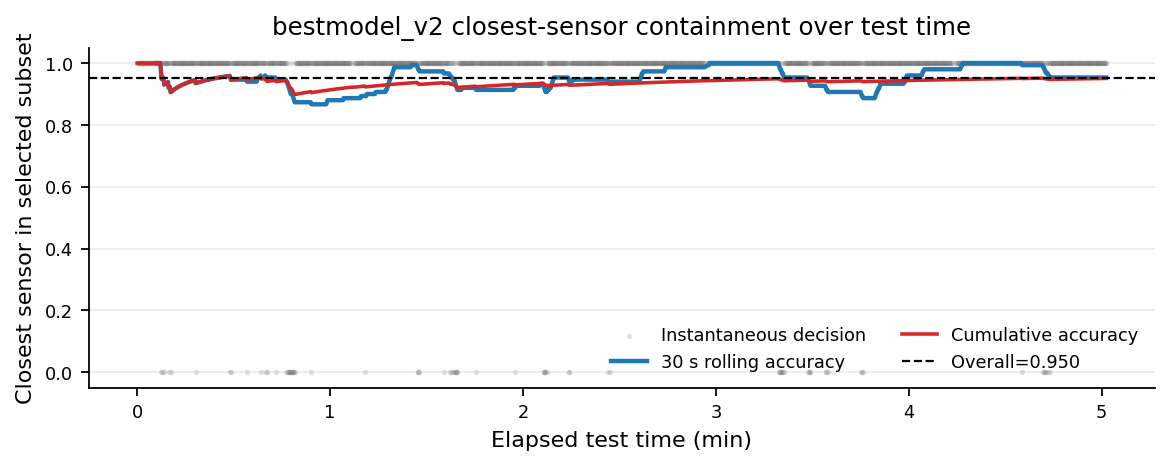

saved d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\reports\figures\bestmodel_v2\bestmodel_v2_full_time_rolling_closest_accuracy.pdf
saved d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\reports\figures\bestmodel_v2\bestmodel_v2_full_time_rolling_closest_accuracy.png


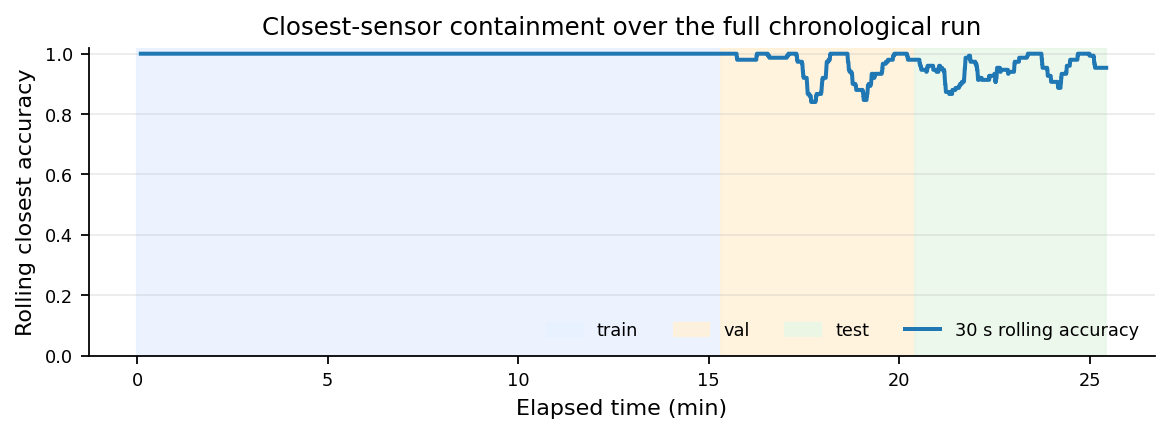

saved d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\reports\figures\bestmodel_v2\bestmodel_v2_split_metric_bars.pdf
saved d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\reports\figures\bestmodel_v2\bestmodel_v2_split_metric_bars.png


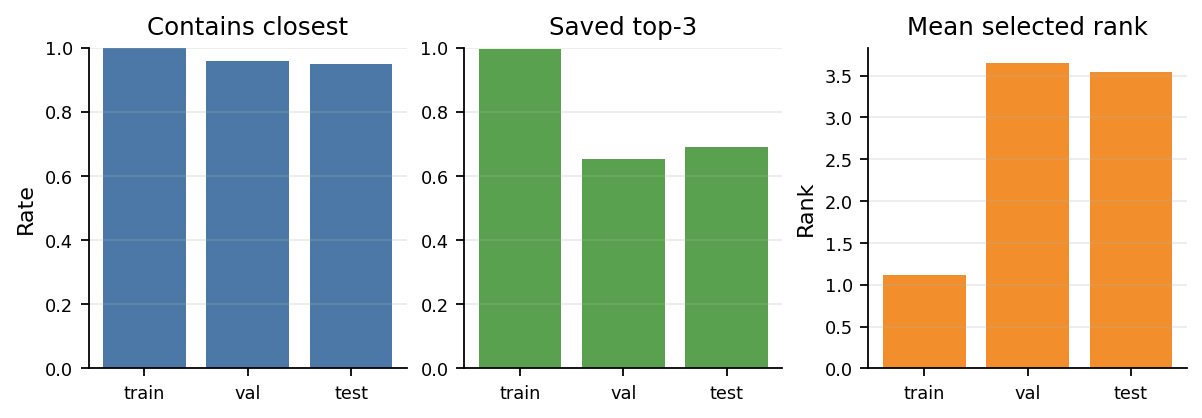

saved d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\reports\figures\bestmodel_v2\bestmodel_v2_validation_history.pdf
saved d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\reports\figures\bestmodel_v2\bestmodel_v2_validation_history.png


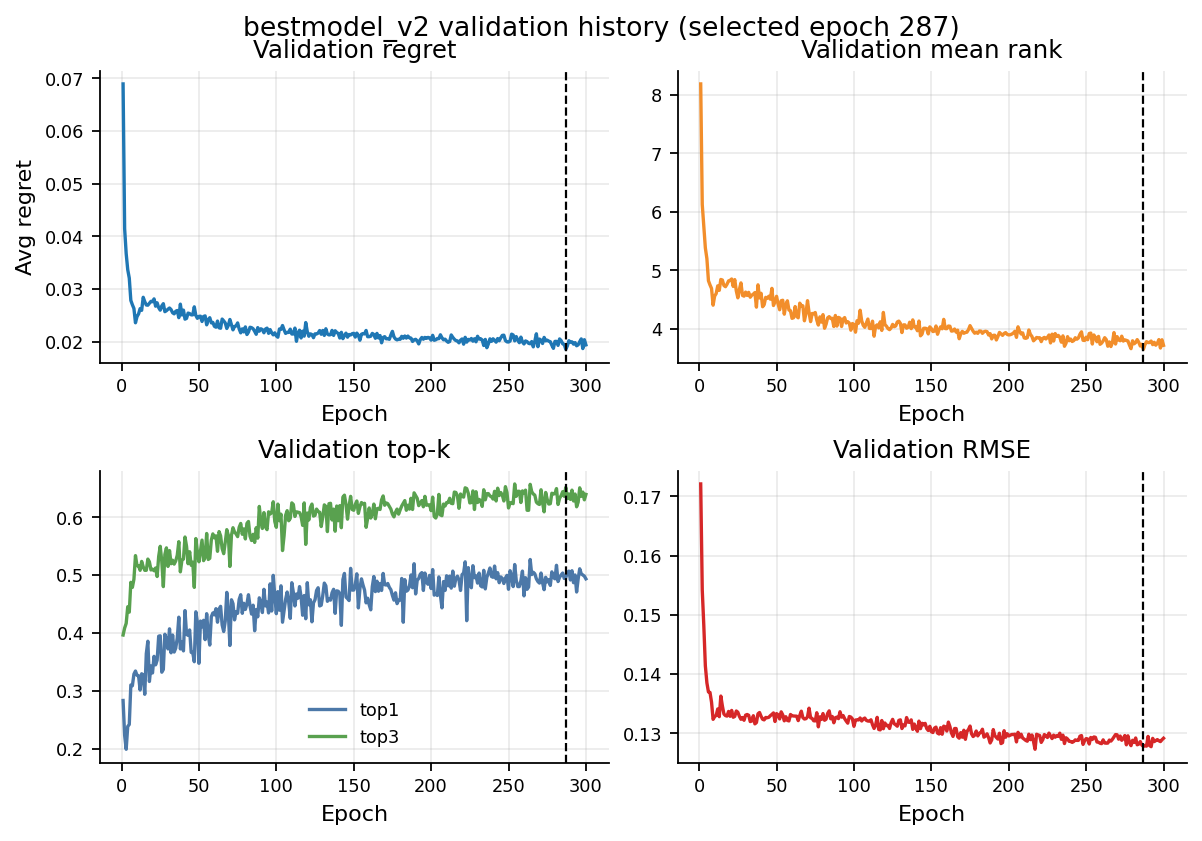

saved d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\reports\figures\bestmodel_v2\bestmodel_v2_test_rank_regret_distributions.pdf
saved d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\reports\figures\bestmodel_v2\bestmodel_v2_test_rank_regret_distributions.png


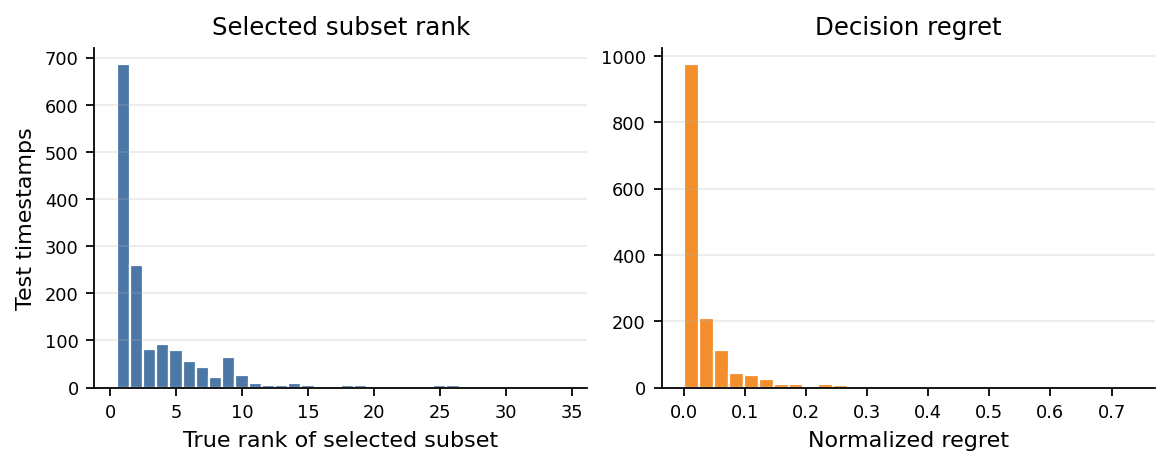

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update(
    {
        "figure.dpi": 160,
        "savefig.dpi": 600,
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

def save_paper_fig(fig, name: str) -> None:
    pdf_path = FIG_DIR / f"{name}.pdf"
    png_path = FIG_DIR / f"{name}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight", dpi=600)
    print("saved", pdf_path)
    print("saved", png_path)

dt_seconds = float(per_time_df["datetime"].sort_values().diff().dt.total_seconds().median())
window_seconds = 30.0
window_n = max(5, int(round(window_seconds / max(dt_seconds, 1e-6))))

# Test-only time vs closest-sensor containment accuracy.
test_time = per_time_df[per_time_df["split"].eq("test")].copy().sort_values("datetime")
test_time["test_elapsed_min"] = (test_time["datetime"] - test_time["datetime"].min()).dt.total_seconds() / 60.0
test_time["rolling_contains_closest"] = test_time["contains_closest"].rolling(window_n, min_periods=max(5, window_n // 5)).mean()
test_time["cumulative_contains_closest"] = test_time["contains_closest"].expanding().mean()
overall_test_rate = float(test_time["contains_closest"].mean())

fig, ax = plt.subplots(figsize=(7.2, 2.8), constrained_layout=True)
ax.scatter(
    test_time["test_elapsed_min"],
    test_time["contains_closest"],
    s=6,
    alpha=0.18,
    color="0.35",
    linewidths=0,
    label="Instantaneous decision",
)
ax.plot(test_time["test_elapsed_min"], test_time["rolling_contains_closest"], color="#1f77b4", lw=2.0, label="30 s rolling accuracy")
ax.plot(test_time["test_elapsed_min"], test_time["cumulative_contains_closest"], color="#d62728", lw=1.6, label="Cumulative accuracy")
ax.axhline(overall_test_rate, color="black", lw=1.0, ls="--", label=f"Overall={overall_test_rate:.3f}")
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Elapsed test time (min)")
ax.set_ylabel("Closest sensor in selected subset")
ax.set_title("bestmodel_v2 closest-sensor containment over test time")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(loc="lower right", ncol=2, frameon=False)
save_paper_fig(fig, "bestmodel_v2_test_time_vs_closest_accuracy")
plt.show()

# Full chronological view with split boundaries.
timeline = per_time_df.copy().sort_values("datetime")
timeline["rolling_contains_closest"] = timeline["contains_closest"].rolling(window_n, min_periods=max(5, window_n // 5)).mean()
fig, ax = plt.subplots(figsize=(7.2, 2.6), constrained_layout=True)
split_colors = {"train": "#e8f1ff", "val": "#fff1d6", "test": "#e8f7e8"}
for split_name, g in timeline.groupby("split", sort=False):
    ax.axvspan(g["elapsed_min"].min(), g["elapsed_min"].max(), color=split_colors.get(split_name, "0.95"), alpha=0.8, label=split_name)
ax.plot(timeline["elapsed_min"], timeline["rolling_contains_closest"], color="#1f77b4", lw=1.8, label="30 s rolling accuracy")
ax.set_ylim(0.0, 1.02)
ax.set_xlabel("Elapsed time (min)")
ax.set_ylabel("Rolling closest accuracy")
ax.set_title("Closest-sensor containment over the full chronological run")
handles, labels = ax.get_legend_handles_labels()
seen = set()
unique = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
ax.legend([h for h, _ in unique], [l for _, l in unique], loc="lower right", ncol=4, frameon=False)
ax.grid(True, axis="y", alpha=0.25)
save_paper_fig(fig, "bestmodel_v2_full_time_rolling_closest_accuracy")
plt.show()

# Split comparison bars.
plot_summary = split_summary_df.set_index("split").loc[["train", "val", "test"]].reset_index()
fig, axes = plt.subplots(1, 3, figsize=(7.4, 2.5), constrained_layout=True)
bar_color = "#4c78a8"
axes[0].bar(plot_summary["split"], plot_summary["contains_closest"], color=bar_color)
axes[0].set_ylim(0, 1.0)
axes[0].set_title("Contains closest")
axes[0].set_ylabel("Rate")
axes[1].bar(plot_summary["split"], plot_summary["saved_top3"], color="#59a14f")
axes[1].set_ylim(0, 1.0)
axes[1].set_title("Saved top-3")
axes[2].bar(plot_summary["split"], plot_summary["mean_rank"], color="#f28e2b")
axes[2].set_title("Mean selected rank")
axes[2].set_ylabel("Rank")
for ax in axes:
    ax.grid(True, axis="y", alpha=0.25)
save_paper_fig(fig, "bestmodel_v2_split_metric_bars")
plt.show()

# Training history for the selected run.
history_path = BEST_DIR / "history.csv"
history_df = pd.read_csv(history_path)
best_epoch = int(best_info["best_epoch"])
fig, axes = plt.subplots(2, 2, figsize=(7.4, 5.0), constrained_layout=True)
axes = axes.ravel()
axes[0].plot(history_df["epoch"], history_df["val_avg_regret"], color="#1f77b4")
axes[0].set_title("Validation regret")
axes[0].set_ylabel("Avg regret")
axes[1].plot(history_df["epoch"], history_df["val_mean_rank"], color="#f28e2b")
axes[1].set_title("Validation mean rank")
axes[2].plot(history_df["epoch"], history_df["val_top1"], label="top1", color="#4c78a8")
axes[2].plot(history_df["epoch"], history_df["val_top3"], label="top3", color="#59a14f")
axes[2].set_title("Validation top-k")
axes[2].legend(frameon=False)
axes[3].plot(history_df["epoch"], history_df["val_rmse"], color="#d62728")
axes[3].set_title("Validation RMSE")
for ax in axes:
    ax.axvline(best_epoch, color="black", lw=1.0, ls="--")
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.25)
fig.suptitle(f"bestmodel_v2 validation history (selected epoch {best_epoch})", y=1.02)
save_paper_fig(fig, "bestmodel_v2_validation_history")
plt.show()

# Test rank/regret distributions.
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8), constrained_layout=True)
rank_bins = np.arange(0.5, per_time_df["saved_rank"].max() + 1.5, 1.0)
axes[0].hist(test_time["saved_rank"], bins=rank_bins, color="#4c78a8", edgecolor="white")
axes[0].set_xlabel("True rank of selected subset")
axes[0].set_ylabel("Test timestamps")
axes[0].set_title("Selected subset rank")
axes[1].hist(test_time["norm_regret"], bins=30, color="#f28e2b", edgecolor="white")
axes[1].set_xlabel("Normalized regret")
axes[1].set_title("Decision regret")
for ax in axes:
    ax.grid(True, axis="y", alpha=0.25)
save_paper_fig(fig, "bestmodel_v2_test_rank_regret_distributions")
plt.show()


saved d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\reports\figures\bestmodel_v2\bestmodel_v2_test_spatial_contains_closest_grid_6m.pdf
saved d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\reports\figures\bestmodel_v2\bestmodel_v2_test_spatial_contains_closest_grid_6m.png


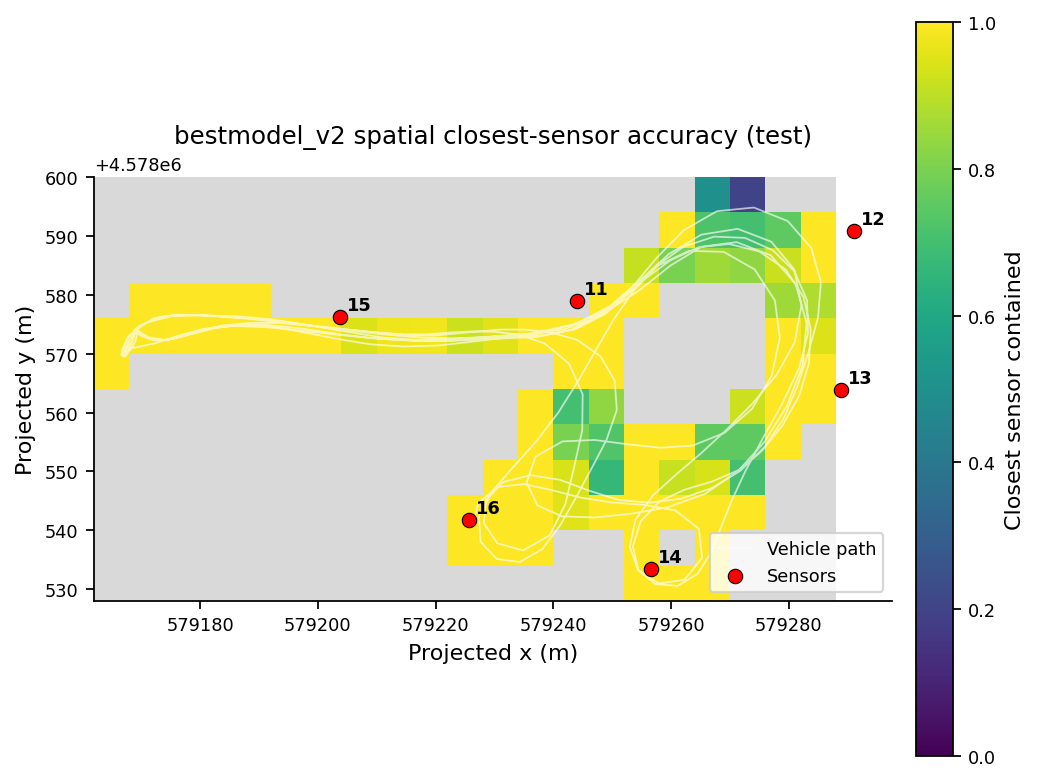

,grid_y,grid_x,n,contains_closest_rate,mean_rank,mean_nearest_distance_m
0,11,18,5,0.200000,14.200000,18.695095
1,11,17,2,0.500000,8.500000,22.937735
2,3,14,6,0.666667,6.833333,18.006282
3,5,13,10,0.700000,4.900000,18.173938
4,3,18,17,0.705882,7.000000,20.977918
5,10,18,17,0.705882,7.294118,18.509219
6,10,17,25,0.720000,7.680000,23.343899
7,4,14,11,0.727273,5.363636,22.603331
8,4,18,16,0.750000,10.625000,17.832510
9,4,17,12,0.750000,9.083333,22.225551


saved d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\reports\figures\bestmodel_v2\bestmodel_v2_test_accuracy_by_closest_sensor.pdf
saved d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\reports\figures\bestmodel_v2\bestmodel_v2_test_accuracy_by_closest_sensor.png


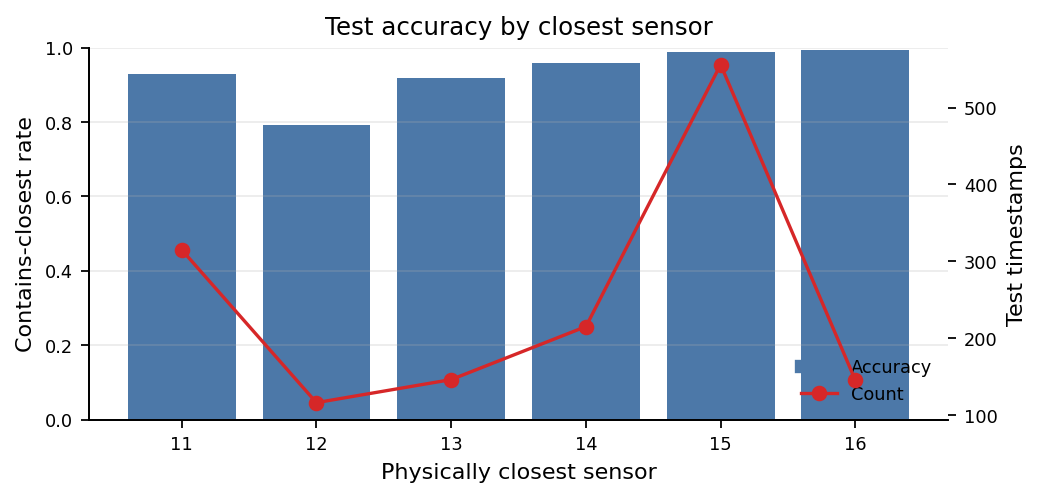

Saved figures to d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\reports\figures\bestmodel_v2
Saved tables to d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26- MILCOM Attempt\reports\tables\bestmodel_v2


,closest_node,n,contains_closest_rate,mean_rank,mean_nearest_distance_m
0,11,315,0.930159,4.488889,12.790386
1,12,116,0.793103,6.439655,16.326771
2,13,146,0.917808,4.828767,13.296942
3,14,215,0.958140,5.093023,12.852851
4,15,556,0.989209,1.762590,22.305658
5,16,145,0.993103,2.427586,11.292858


In [3]:
from matplotlib.lines import Line2D

vehicle_gt_path = PROCESSED_DIR / f"{PREFIX}_ground_truth_vehicle.csv"
sensor_geometry_path = PROCESSED_DIR / f"{PREFIX}_sensor_geometry.csv"
vehicle_gt = pd.read_csv(vehicle_gt_path)
vehicle_gt["datetime"] = pd.to_datetime(vehicle_gt["datetime"])
sensor_geometry = pd.read_csv(sensor_geometry_path)

spatial_df = per_time_df.merge(vehicle_gt, on="datetime", how="left", suffixes=("", "_gt"))
if "closest_node_gt" in spatial_df.columns:
    spatial_df["closest_node"] = spatial_df["closest_node_gt"].fillna(spatial_df["closest_node"]).astype(int)
spatial_df.to_csv(TABLE_DIR / "bestmodel_v2_spatial_decisions.csv", index=False)

def plot_spatial_grid(df: pd.DataFrame, split_name: str, grid_m: float = 6.0) -> pd.DataFrame:
    d = df[df["split"].eq(split_name)].dropna(subset=["vehicle_x_m", "vehicle_y_m"]).copy()
    x_min = np.floor(d["vehicle_x_m"].min() / grid_m) * grid_m
    y_min = np.floor(d["vehicle_y_m"].min() / grid_m) * grid_m
    d["grid_x"] = np.floor((d["vehicle_x_m"] - x_min) / grid_m).astype(int)
    d["grid_y"] = np.floor((d["vehicle_y_m"] - y_min) / grid_m).astype(int)
    cell_df = (
        d.groupby(["grid_y", "grid_x"])
        .agg(
            n=("time_id", "count"),
            contains_closest_rate=("contains_closest", "mean"),
            mean_rank=("saved_rank", "mean"),
            mean_nearest_distance_m=("nearest_distance_m", "mean"),
        )
        .reset_index()
    )
    nx = int(cell_df["grid_x"].max()) + 1
    ny = int(cell_df["grid_y"].max()) + 1
    grid = np.full((ny, nx), np.nan, dtype=float)
    counts = np.zeros((ny, nx), dtype=int)
    for row in cell_df.itertuples(index=False):
        grid[int(row.grid_y), int(row.grid_x)] = float(row.contains_closest_rate)
        counts[int(row.grid_y), int(row.grid_x)] = int(row.n)

    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad("#d9d9d9")
    fig, ax = plt.subplots(figsize=(6.4, 4.8), constrained_layout=True)
    extent = [x_min, x_min + nx * grid_m, y_min, y_min + ny * grid_m]
    im = ax.imshow(grid, origin="lower", extent=extent, cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")
    ax.plot(d["vehicle_x_m"], d["vehicle_y_m"], color="white", lw=0.8, alpha=0.65, label="Vehicle path")
    ax.scatter(sensor_geometry["sensor_x_m"], sensor_geometry["sensor_y_m"], s=42, c="red", edgecolors="black", linewidths=0.5, label="Sensors", zorder=4)
    for row in sensor_geometry.itertuples(index=False):
        ax.text(row.sensor_x_m + 1.2, row.sensor_y_m + 1.2, str(int(row.node)), fontsize=8, color="black", weight="bold")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cbar.set_label("Closest sensor contained")
    ax.set_title(f"bestmodel_v2 spatial closest-sensor accuracy ({split_name})")
    ax.set_xlabel("Projected x (m)")
    ax.set_ylabel("Projected y (m)")
    ax.legend(loc="lower right", frameon=True)
    save_paper_fig(fig, f"bestmodel_v2_{split_name}_spatial_contains_closest_grid_{int(grid_m)}m")
    plt.show()
    cell_df.to_csv(TABLE_DIR / f"bestmodel_v2_{split_name}_spatial_grid_{int(grid_m)}m.csv", index=False)
    return cell_df.sort_values(["contains_closest_rate", "n"], ascending=[True, False]).reset_index(drop=True)

test_cell_df = plot_spatial_grid(spatial_df, "test", grid_m=6.0)
display(test_cell_df.head(20))

# Accuracy by physically closest sensor.
test_spatial = spatial_df[spatial_df["split"].eq("test")].dropna(subset=["closest_node"]).copy()
sensor_rate_df = (
    test_spatial.groupby("closest_node")
    .agg(
        n=("time_id", "count"),
        contains_closest_rate=("contains_closest", "mean"),
        mean_rank=("saved_rank", "mean"),
        mean_nearest_distance_m=("nearest_distance_m", "mean"),
    )
    .reset_index()
    .sort_values("closest_node")
)
sensor_rate_df.to_csv(TABLE_DIR / "bestmodel_v2_test_accuracy_by_closest_sensor.csv", index=False)

fig, ax1 = plt.subplots(figsize=(6.4, 3.0), constrained_layout=True)
ax1.bar(sensor_rate_df["closest_node"].astype(str), sensor_rate_df["contains_closest_rate"], color="#4c78a8")
ax1.set_ylim(0, 1.0)
ax1.set_xlabel("Physically closest sensor")
ax1.set_ylabel("Contains-closest rate")
ax1.grid(True, axis="y", alpha=0.25)
ax2 = ax1.twinx()
ax2.plot(sensor_rate_df["closest_node"].astype(str), sensor_rate_df["n"], color="#d62728", marker="o", lw=1.5)
ax2.set_ylabel("Test timestamps")
ax1.set_title("Test accuracy by closest sensor")
legend_items = [
    Line2D([0], [0], color="#4c78a8", lw=6, label="Accuracy"),
    Line2D([0], [0], color="#d62728", marker="o", lw=1.5, label="Count"),
]
ax1.legend(handles=legend_items, loc="lower right", frameon=False)
save_paper_fig(fig, "bestmodel_v2_test_accuracy_by_closest_sensor")
plt.show()

print("Saved figures to", FIG_DIR)
print("Saved tables to", TABLE_DIR)
display(sensor_rate_df)
